In [1]:
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

from navigoquest.utils.config import standard_dirs, LEVELS, METADATA_COLS, AGE_RANGE
from navigoquest import format_metric_task_data
from navigoquest.utils.pipelines import load_environment, load_paths_normative, pipeline_compute_features
from navigoquest.utils.figures import save_figure
from navigoquest.utils.stat_report import welch_ttest, tests_frame, adjust_pvalues, save_tests

In [2]:
# Settings common over levels
metric_filenames_benchmark = {lvl: f"metrics_level{lvl:02}_gb_2480.csv" for lvl in np.arange(1, 99)}
metric_names = ['duration', 'path_length', 'average_curvature', 'boundary_affinity',
             'frobenius_deviation', 'supremum_deviation', 'conformity', 'vector_conformity']
metric_names_withvoc = ['voc'] + metric_names
levels = LEVELS

# Directories
dirs = standard_dirs()
paths_dir = dirs['paths']
output_dir = dirs['output']
if not output_dir.exists():
    output_dir.mkdir(parents=True)

# Load environment
env_store = load_environment(dirs)

# Load benchmark metric dataframes
metrics_benchmark_loaded = {lvl: pd.read_csv(output_dir / metric_filenames_benchmark[lvl]) for lvl in levels}

# Load clinical metric dataframes
metrics_clinical_loaded = pd.read_csv(output_dir / 'clinical_metrics.csv')

Loading environment data...
done. 



# Mean & std wrt. VOC (Benchmark grp.)

In [3]:
mean_voc0, mean_voc1 = {}, {}
std_voc0, std_voc1 = {}, {}

for lvl in levels:
    # Dataframe of concern
    df = metrics_benchmark_loaded[lvl]
    df_voc0 = df[df['voc'] == 0]
    df_voc1 = df[df['voc'] == 1]
    for metric in metric_names:
        # Mean and std
        arr_voc0 = df_voc0[metric].to_numpy()
        arr_voc1 = df_voc1[metric].to_numpy()
        item_mean_voc0, item_std_voc0 = np.mean(arr_voc0), np.std(arr_voc0)
        item_mean_voc1, item_std_voc1 = np.mean(arr_voc1), np.std(arr_voc1)

        # Store
        mean_voc0[(lvl, metric)] = item_mean_voc0
        mean_voc1[(lvl, metric)] = item_mean_voc1
        std_voc0[(lvl, metric)] = item_std_voc0
        std_voc1[(lvl, metric)] = item_std_voc1


Saved 'variance_ratio': variance_ratio.pdf, variance_ratio.svg, source_data/variance_ratio.xlsx (tabs: variance_ratio)


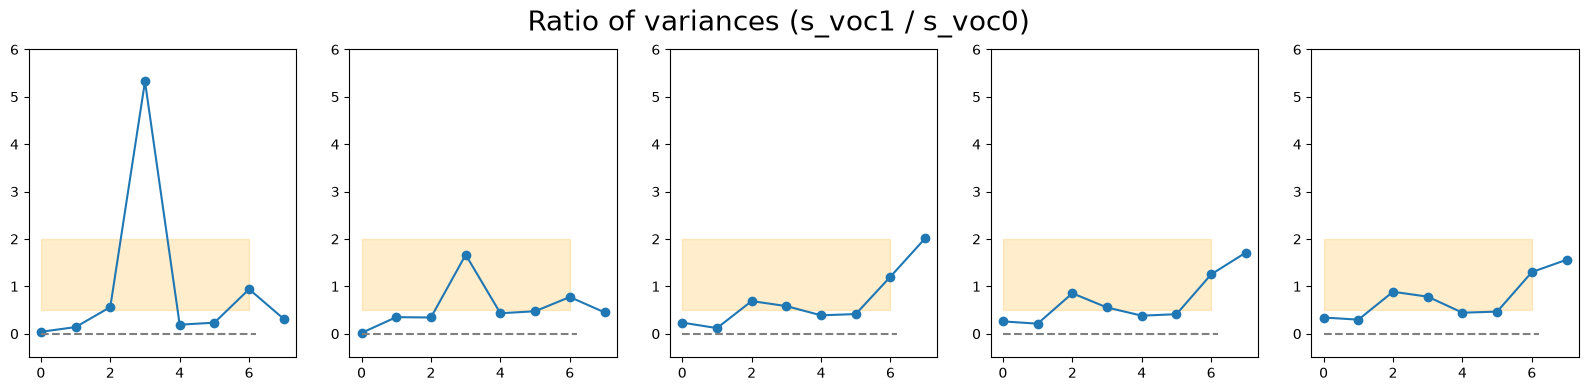

In [4]:
fig, ax = plt.subplots(ncols=len(levels), nrows=1)
fig.set_size_inches(4 * len(levels), 4)

for i, lvl in enumerate(levels):
    std0_now = np.array([std_voc0[(lvl, metric)] for metric in metric_names])
    std1_now = np.array([std_voc1[(lvl, metric)] for metric in metric_names])

    ax[i].plot(std1_now / std0_now, marker='o')

    ax[i].set_ylim([-0.5, 6])
    ax[i].plot([0, 6.2], [0, 0], c='gray', linestyle='--')
    ax[i].fill_between(np.arange(7), 0.5 * np.ones(7), 2 * np.ones(7), alpha=0.2, color='orange')

plt.suptitle(f'Ratio of variances (s_voc1 / s_voc0)', fontsize=20)

save_figure(fig, "variance_ratio")

# t-test (Benchmark)

In [5]:
ttest_pvals = {}
benchmark_tests = []  # full results (df, effect size, CIs), reported below

for lvl in levels:
    # Dataframe of concern
    df = metrics_benchmark_loaded[lvl]
    df_voc0 = df[df['voc'] == 0]
    df_voc1 = df[df['voc'] == 1]
    for metric in metric_names:
        # VOC groups
        arr_voc0 = df_voc0[metric].to_numpy()
        arr_voc1 = df_voc1[metric].to_numpy()

        # Welch's t-test (as scipy's ttest_ind with equal_var=False), with df, Cohen's d and 95% CIs
        test_output = welch_ttest(arr_voc0, arr_voc1, group1='incorrect VOC', group2='correct VOC',
                                  level=lvl, metric=metric)
        pval = test_output['p']

        # Store
        ttest_pvals[(lvl, metric)] = pval
        benchmark_tests.append(test_output)

In [6]:
multiplier_bonferroni = 24

for i, lvl in enumerate(levels):
    pvals_now = multiplier_bonferroni * np.array([ttest_pvals[(lvl, metric)] for metric in metric_names])
    print(f'Level {lvl}: Bonf. corrected p-values for the metrics are: {pvals_now} \n')

Level 1: Bonf. corrected p-values for the metrics are: [1.02181576e-03 7.86696037e-07 3.87265933e-06 4.41804552e-06
 5.33484382e-02 3.63778774e-02 9.31429175e-11 2.37616309e-01] 

Level 2: Bonf. corrected p-values for the metrics are: [1.78558406e-07 1.40346873e-16 2.46793801e-23 9.41761292e-11
 1.38033440e-11 6.56680097e-12 9.71089550e-29 9.04555919e-11] 

Level 6: Bonf. corrected p-values for the metrics are: [0. 0. 0. 0. 0. 0. 0. 0.] 

Level 8: Bonf. corrected p-values for the metrics are: [0. 0. 0. 0. 0. 0. 0. 0.] 

Level 11: Bonf. corrected p-values for the metrics are: [0. 0. 0. 0. 0. 0. 0. 0.] 



In [7]:
# Report in the journal's format: t(df) = value, p = value, Cohen's d = value, 95% CI = [low, high],
# with the Bonferroni correction above. Written to statistical_tests/benchmark_voc_ttests.csv and .txt
benchmark_tests_df = adjust_pvalues(tests_frame(benchmark_tests), "bonferroni", n_tests=multiplier_bonferroni)
benchmark_tests_df = save_tests(
    benchmark_tests_df,
    "benchmark_voc_ttests",
    title="Benchmark group: incorrect vs. correct visiting order (VOC), Welch's t-tests",
    description="All players of the benchmark group, per level and metric (7_t_test.ipynb). "
    f"Bonferroni: p x {multiplier_bonferroni}, as in the notebook.",
)

Benchmark group: incorrect vs. correct visiting order (VOC), Welch's t-tests -> /Users/uzulim/Documents/code/navigation_geometry4/navigoquest/statistical_tests/benchmark_voc_ttests.csv/.txt
[level = 1, metric = duration] t(19.0) = 5.28, p = 4.26 × 10⁻⁵ (Bonferroni-adjusted p = 0.00102), Cohen's d = 29.30, 95% CI = [28.85, 29.75]; mean difference (incorrect VOC − correct VOC) = 974, 95% CI = [588, 1360]; n = 20 vs. 171942
[level = 1, metric = path_length] t(19.0) = 8.91, p = 3.28 × 10⁻⁸ (Bonferroni-adjusted p = 7.87 × 10⁻⁷), Cohen's d = 14.63, 95% CI = [14.18, 15.07]; mean difference (incorrect VOC − correct VOC) = 140, 95% CI = [107, 173]; n = 20 vs. 171942
[level = 1, metric = average_curvature] t(19.0) = 8.02, p = 1.61 × 10⁻⁷ (Bonferroni-adjusted p = 3.87 × 10⁻⁶), Cohen's d = 3.28, 95% CI = [2.84, 3.72]; mean difference (incorrect VOC − correct VOC) = 0.187, 95% CI = [0.138, 0.236]; n = 20 vs. 171942
[level = 1, metric = boundary_affinity] t(19.1) = −7.93, p = 1.84 × 10⁻⁷ (Bonferroni

# t-test (Clinical)

In [8]:
ttest_pvals_e3_ad = {}
ttest_pvals_e3_e4 = {}
clinical_tests = []  # full results (df, effect size, CIs), reported below

for lvl in levels:
    # Dataframe of concern
    df = metrics_clinical_loaded
    df_e3 = df[(df['level'] == lvl) & (df['group'] == 'e3e3')]
    df_e4 = df[(df['level'] == lvl) & (df['group'] == 'e3e4')]
    df_ad = df[(df['level'] == lvl) & (df['group'] == 'ad')]
    for metric in metric_names:
        # VOC groups
        arr_e3 = df_e3[metric].to_numpy()
        arr_e4 = df_e4[metric].to_numpy()
        arr_ad = df_ad[metric].to_numpy()

        # Welch's t-test (as scipy's ttest_ind with equal_var=False), with df, Cohen's d and 95% CIs
        test_output_e3_ad = welch_ttest(arr_e3, arr_ad, group1='e3e3', group2='AD',
                                        comparison='e3e3 vs. AD', level=lvl, metric=metric)
        test_output_e3_e4 = welch_ttest(arr_e3, arr_e4, group1='e3e3', group2='e3e4',
                                        comparison='e3e3 vs. e3e4', level=lvl, metric=metric)

        pval_e3_ad = test_output_e3_ad['p']
        pval_e3_e4 = test_output_e3_e4['p']
        
        # Store
        ttest_pvals_e3_ad[(lvl, metric)] = pval_e3_ad
        ttest_pvals_e3_e4[(lvl, metric)] = pval_e3_e4
        clinical_tests += [test_output_e3_ad, test_output_e3_e4]

In [9]:
for i, lvl in enumerate(levels):
    pvals_now = np.array([ttest_pvals_e3_ad[(lvl, metric)] for metric in metric_names])
    print(f'e3e3 vs. AD, Level {lvl}: p-values for the metrics are: {pvals_now} \n')

for i, lvl in enumerate(levels):
    pvals_now = np.array([ttest_pvals_e3_e4[(lvl, metric)] for metric in metric_names])
    print(f'e3e3 vs. e3e4, Level {lvl}: p-values for the metrics are: {pvals_now} \n')

e3e3 vs. AD, Level 1: p-values for the metrics are: [5.62180990e-03 4.86006177e-02 1.42595918e-03 1.65853822e-02
 3.31771387e-02 5.30526602e-02 3.97045113e-03 8.49672085e-05] 

e3e3 vs. AD, Level 2: p-values for the metrics are: [0.00085358 0.0034588  0.00592165 0.00676825 0.00424154 0.01170348
 0.00168675 0.00019304] 

e3e3 vs. AD, Level 6: p-values for the metrics are: [1.17050315e-04 6.34075300e-06 2.82485361e-04 1.30583409e-03
 1.92502213e-03 2.30752509e-03 7.39458168e-13 9.87575950e-14] 

e3e3 vs. AD, Level 8: p-values for the metrics are: [1.46090511e-03 9.81496916e-05 4.21059130e-03 1.85940470e-02
 2.23907001e-02 3.87226920e-02 3.87755948e-05 1.06460076e-06] 

e3e3 vs. AD, Level 11: p-values for the metrics are: [0.01094974 0.00510084 0.02379523 0.06266743 0.12774251 0.24622805
 0.00436333 0.04392709] 

e3e3 vs. e3e4, Level 1: p-values for the metrics are: [0.84052428 0.82831306 0.37717966 0.5388179  0.31657739 0.34996211
 0.42162097 0.62440555] 

e3e3 vs. e3e4, Level 2: p-value

In [10]:
multiplier_bonferroni = 48

for i, lvl in enumerate([6, 8, 11]):
    pvals_now = multiplier_bonferroni * np.array([ttest_pvals_e3_ad[(lvl, metric)] for metric in metric_names])
    print(f'e3e3 vs. AD, Level {lvl}: Bonf. corrected p-values for the metrics are: \n {pvals_now} \n\n')

for i, lvl in enumerate([6, 8, 11]):
    pvals_now = multiplier_bonferroni * np.array([ttest_pvals_e3_e4[(lvl, metric)] for metric in metric_names])
    print(f'e3e3 vs. e3e4, Level {lvl}: Bonf. corrected p-values for the metrics are: \n {pvals_now} \n\n')

e3e3 vs. AD, Level 6: Bonf. corrected p-values for the metrics are: 
 [5.61841511e-03 3.04356144e-04 1.35592973e-02 6.26800362e-02
 9.24010620e-02 1.10761204e-01 3.54939921e-11 4.74036456e-12] 


e3e3 vs. AD, Level 8: Bonf. corrected p-values for the metrics are: 
 [7.01234451e-02 4.71118520e-03 2.02108383e-01 8.92514257e-01
 1.07475360e+00 1.85868922e+00 1.86122855e-03 5.11008365e-05] 


e3e3 vs. AD, Level 11: Bonf. corrected p-values for the metrics are: 
 [ 0.52558757  0.24484017  1.14217094  3.00803687  6.13164045 11.81894657
  0.20943998  2.10850027] 


e3e3 vs. e3e4, Level 6: Bonf. corrected p-values for the metrics are: 
 [ 6.46404185  1.17751877 16.33725767 28.40837607 39.84187168 46.73095568
  1.44241688 18.164588  ] 


e3e3 vs. e3e4, Level 8: Bonf. corrected p-values for the metrics are: 
 [ 3.46824149  1.61071671 39.19028928 11.20501009 29.91206185 37.07906648
  0.89514588 29.69628737] 


e3e3 vs. e3e4, Level 11: Bonf. corrected p-values for the metrics are: 
 [ 1.73703983  

# Benjamini-Hochberg correction (Clinical)

In [11]:
# Form a single array
pvals_e3_ad = [[ttest_pvals_e3_ad[(lvl, metric)] for metric in metric_names] for lvl in [6, 8, 11]]
pvals_e3_e4 = [[ttest_pvals_e3_e4[(lvl, metric)] for metric in metric_names] for lvl in [6, 8, 11]]
pvals_all = np.array([pvals_e3_ad, pvals_e3_e4])

# Flattened, and ranks
pvals_all_flat = pvals_all.flatten()
pvals_all_rank = 1 + np.argsort(np.argsort(pvals_all_flat)).reshape(pvals_all.shape)

# Perform checks
checker = np.array([pvals_all[np.nonzero(pvals_all_rank == (i+1))] for i in range(pvals_all_flat.size)])
checker = (checker[1:] - checker[:-1]) > 0
print(f'Checks: {np.sum(checker)}/{checker.size}')
if np.all(checker):
    print(f'All checks passed.')

# Benjamini-Hochberg correction
benhoch_factors = pvals_all_rank.size / pvals_all_rank
pvals_benhoch = pvals_all * benhoch_factors

Checks: 47/47
All checks passed.


In [12]:
np.set_printoptions(precision=3)

print(f'p-values (uncorrected):')
print(pvals_all)

print(f'\n p-values (BH correction):')
print(pvals_benhoch)

p-values (uncorrected):
[[[1.171e-04 6.341e-06 2.825e-04 1.306e-03 1.925e-03 2.308e-03 7.395e-13
   9.876e-14]
  [1.461e-03 9.815e-05 4.211e-03 1.859e-02 2.239e-02 3.872e-02 3.878e-05
   1.065e-06]
  [1.095e-02 5.101e-03 2.380e-02 6.267e-02 1.277e-01 2.462e-01 4.363e-03
   4.393e-02]]

 [[1.347e-01 2.453e-02 3.404e-01 5.918e-01 8.300e-01 9.736e-01 3.005e-02
   3.784e-01]
  [7.226e-02 3.356e-02 8.165e-01 2.334e-01 6.232e-01 7.725e-01 1.865e-02
   6.187e-01]
  [3.619e-02 2.680e-02 3.268e-01 2.652e-02 2.159e-01 2.946e-01 5.496e-02
   3.172e-01]]]

 p-values (BH correction):
[[[8.026e-04 7.609e-05 1.695e-03 6.964e-03 8.400e-03 9.230e-03 1.775e-11
   4.740e-12]
  [7.012e-03 7.852e-04 1.555e-02 5.250e-02 5.657e-02 6.884e-02 3.722e-04
   1.703e-05]
  [3.285e-02 1.632e-02 5.711e-02 1.003e-01 1.916e-01 3.283e-01 1.496e-02
   7.530e-02]]

 [[1.959e-01 5.607e-02 4.084e-01 6.764e-01 8.477e-01 9.736e-01 6.010e-02
   4.430e-01]
  [1.119e-01 6.443e-02 8.520e-01 3.201e-01 6.798e-01 8.240e-01 4.973e-02

# Report of the clinical t-tests

In the journal's format: t(df) = value, p = value, Cohen's d = value, 95% CI = [low, high]. Written to `statistical_tests/clinical_ttests.csv` and `.txt`.

In [13]:
# Corrections as above, over the 48 tests of levels 6, 8 and 11: Bonferroni (p x 48) and
# Benjamini-Hochberg (standard step-up adjusted p-values). Levels 1 and 2 are reported unadjusted.
clinical_tests_df = tests_frame(pd.DataFrame(clinical_tests).sort_values(['comparison', 'level'], kind='stable'))
family = clinical_tests_df['level'].isin([6, 8, 11])
clinical_tests_df = adjust_pvalues(clinical_tests_df, "bonferroni", n_tests=48, where=family)
clinical_tests_df = adjust_pvalues(clinical_tests_df, "bh", where=family)

clinical_tests_df = save_tests(
    clinical_tests_df,
    "clinical_ttests",
    title="Clinical groups: e3e3 vs. AD and e3e3 vs. e3e4, Welch's t-tests",
    description="Clinical cohort, per level and metric (7_t_test.ipynb). Adjusted p-values "
    "(Bonferroni x 48 and Benjamini-Hochberg over 48 tests) for levels 6, 8 and 11 only.",
)

Clinical groups: e3e3 vs. AD and e3e3 vs. e3e4, Welch's t-tests -> /Users/uzulim/Documents/code/navigation_geometry4/navigoquest/statistical_tests/clinical_ttests.csv/.txt
[comparison = e3e3 vs. AD, level = 1, metric = duration] t(20.1) = −3.10, p = 0.00562, Cohen's d = −1.04, 95% CI = [−1.64, −0.43]; mean difference (e3e3 − AD) = −39.3, 95% CI = [−65.7, −12.9]; n = 28 vs. 21
[comparison = e3e3 vs. AD, level = 1, metric = path_length] t(20.1) = −2.10, p = 0.0486, Cohen's d = −0.70, 95% CI = [−1.28, −0.12]; mean difference (e3e3 − AD) = −11.8, 95% CI = [−23.5, −0.1]; n = 28 vs. 21
[comparison = e3e3 vs. AD, level = 1, metric = average_curvature] t(24.5) = −3.59, p = 0.00143, Cohen's d = −1.16, 95% CI = [−1.77, −0.55]; mean difference (e3e3 − AD) = −0.082, 95% CI = [−0.129, −0.035]; n = 28 vs. 21
[comparison = e3e3 vs. AD, level = 1, metric = boundary_affinity] t(20.1) = −2.61, p = 0.0166, Cohen's d = −0.87, 95% CI = [−1.47, −0.28]; mean difference (e3e3 − AD) = −4.94, 95% CI = [−8.89, −

# Cohen's d Effect Sizes (Clinical)

In [14]:
def cohens_d(a, b):
    n_a, n_b = len(a), len(b)
    pooled_std = np.sqrt(((n_a - 1) * np.var(a, ddof=1) + (n_b - 1) * np.var(b, ddof=1)) / (n_a + n_b - 2))
    return (np.mean(a) - np.mean(b)) / pooled_std


cohens_d_e3_ad = {}
cohens_d_e3_e4 = {}

for lvl in levels:
    df = metrics_clinical_loaded
    df_e3 = df[(df['level'] == lvl) & (df['group'] == 'e3e3')]
    df_e4 = df[(df['level'] == lvl) & (df['group'] == 'e3e4')]
    df_ad = df[(df['level'] == lvl) & (df['group'] == 'ad')]
    for metric in metric_names:
        arr_e3 = df_e3[metric].to_numpy()
        arr_e4 = df_e4[metric].to_numpy()
        arr_ad = df_ad[metric].to_numpy()
        cohens_d_e3_ad[(lvl, metric)] = cohens_d(arr_e3, arr_ad)
        cohens_d_e3_e4[(lvl, metric)] = cohens_d(arr_e3, arr_e4)

np.set_printoptions(precision=3)

print("Cohen's d  (e3e3 vs. AD):")
for lvl in [6, 8, 11]:
    d_vals = np.array([cohens_d_e3_ad[(lvl, metric)] for metric in metric_names])
    print(f"  Level {lvl:2d}: {d_vals}")

print("\nCohen's d  (e3e3 vs. e3e4):")
for lvl in [6, 8, 11]:
    d_vals = np.array([cohens_d_e3_e4[(lvl, metric)] for metric in metric_names])
    print(f"  Level {lvl:2d}: {d_vals}")

Cohen's d  (e3e3 vs. AD):
  Level  6: [-1.863 -2.395 -1.656 -1.402 -1.347 -1.285 -3.029 -2.967]
  Level  8: [-1.718 -2.176 -1.344 -1.152 -1.114 -0.976 -1.484 -1.657]
  Level 11: [-1.577 -1.858 -1.222 -1.091 -0.806 -0.578 -1.142 -0.85 ]

Cohen's d  (e3e3 vs. e3e4):
  Level  6: [-0.386 -0.586 -0.248  0.138 -0.056  0.009 -0.572 -0.229]
  Level  8: [-0.464 -0.555 -0.061 -0.317 -0.128  0.076 -0.633 -0.129]
  Level 11: [-0.552 -0.58  -0.256 -0.583 -0.321 -0.271 -0.506 -0.261]


# Raw scores

In [15]:
def fmt_mean_std(arr):
    means = np.mean(arr, axis=0)
    stds = np.std(arr, axis=0)
    return ', '.join(f'{m:.3f} ± {s:.3f}' for m, s in zip(means, stds))

for lvl in [6, 8, 11]:
    df = metrics_clinical_loaded
    df_e3 = df[(df['level'] == lvl) & (df['group'] == 'e3e3')]
    df_e4 = df[(df['level'] == lvl) & (df['group'] == 'e3e4')]
    df_ad = df[(df['level'] == lvl) & (df['group'] == 'ad')]

    arr_e3 = df_e3[metric_names].to_numpy()
    arr_e4 = df_e4[metric_names].to_numpy()
    arr_ad = df_ad[metric_names].to_numpy()

    print(f'Level {lvl}, e3e3: {fmt_mean_std(arr_e3)}')
    print(f'Level {lvl}, e3e4: {fmt_mean_std(arr_e4)}')
    print(f'Level {lvl}, ad:   {fmt_mean_std(arr_ad)}')
    print()

Level 6, e3e3: 34.666 ± 9.214, 66.166 ± 8.930, 0.075 ± 0.022, 0.947 ± 0.347, 14.954 ± 9.988, 12.114 ± 10.672, -0.236 ± 0.045, -0.165 ± 0.046
Level 6, e3e4: 39.897 ± 16.136, 80.024 ± 30.915, 0.082 ± 0.026, 0.884 ± 0.530, 15.588 ± 12.183, 12.012 ± 12.439, -0.205 ± 0.061, -0.153 ± 0.056
Level 6, ad:   127.866 ± 77.373, 170.690 ± 67.324, 0.177 ± 0.092, 2.299 ± 1.444, 56.192 ± 46.197, 43.357 ± 35.622, -0.104 ± 0.039, -0.041 ± 0.031

Level 8, e3e3: 76.471 ± 25.730, 157.670 ± 46.554, 0.114 ± 0.024, 0.454 ± 0.433, 25.157 ± 18.446, 20.004 ± 19.893, -0.114 ± 0.034, -0.103 ± 0.044
Level 8, e3e4: 97.721 ± 57.028, 197.458 ± 86.592, 0.115 ± 0.024, 0.584 ± 0.375, 27.831 ± 22.378, 18.487 ± 19.458, -0.093 ± 0.033, -0.097 ± 0.052
Level 8, ad:   288.371 ± 200.816, 375.597 ± 152.910, 0.171 ± 0.062, 2.370 ± 2.685, 110.069 ± 123.426, 79.225 ± 96.512, -0.065 ± 0.030, -0.036 ± 0.030

Level 11, e3e3: 95.515 ± 30.079, 188.287 ± 29.501, 0.117 ± 0.022, 0.907 ± 0.328, 26.539 ± 18.193, 17.113 ± 17.059, -0.165 ± 0.0